In [ ]:
%matplotlib widget

import os
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".15"

import abtem
import ase
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
from jax_multislice import get_abtem_transmit, Propagator as convolve2d, energy2wavelength, fresnel_propagation_kernel, angular_spectrum_propagation_kernel

abtem.config.set({"device": "cpu"});

NumPy version: 1.26.4
JAX version: 0.4.25


In [117]:
atoms = ase.Atoms('Au', cell=[20, 20, 20], pbc=True)
atoms.center()


In [118]:
base_sampling = 0.05
base_slice_thickness = 0.05

potential = abtem.Potential(
    atoms,
    sampling=base_sampling,
    slice_thickness=base_slice_thickness,
    projection='finite',
)
print(potential.shape)

(400, 400, 400)


(<Figure size 1000x400 with 2 Axes>,
 <Axes: title={'center': 'Top view'}, xlabel='x [Å]', ylabel='z [Å]'>)

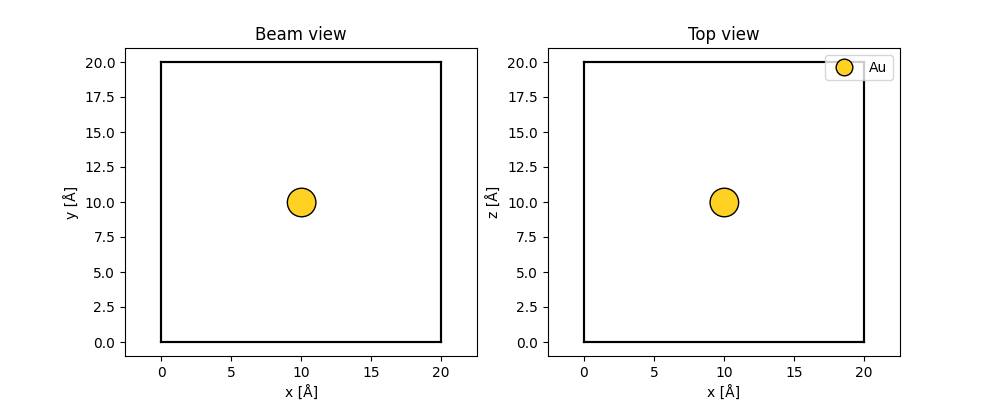

In [119]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
abtem.show_atoms(atoms, ax=ax1, title="Beam view", merge=False)
abtem.show_atoms(atoms, ax=ax2, plane="xz", title="Top view", legend=True)

In [120]:
energy = 200e3
transmit = get_abtem_transmit(potential, energy)

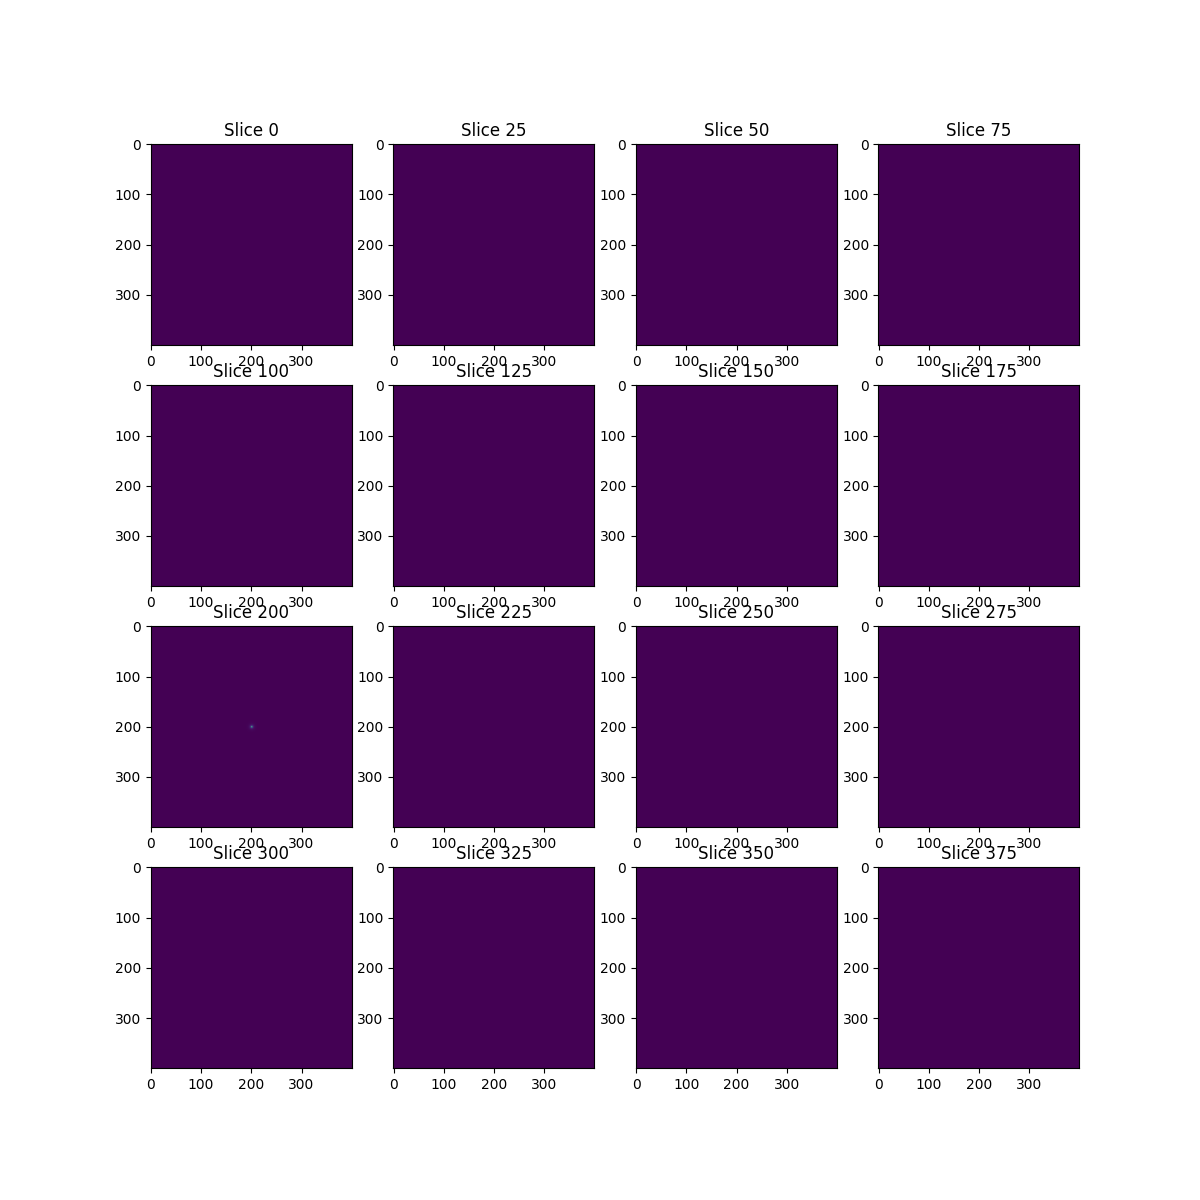

In [121]:
potential_array = potential.build(lazy=False).array
subset = potential_array[::25]

rows = int(np.floor(np.sqrt(len(subset))))
cols = int(np.ceil(np.sqrt(len(subset))))
if rows * cols < len(subset):
    cols += 1
fig, ax = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
vmin = potential_array.min()
vmax = potential_array.max()
for i, (p, s_ax) in enumerate(zip(subset, ax.ravel())):
    s_ax.imshow(p, vmin=vmin, vmax=vmax)
    s_ax.set_title(f"Slice {i * 25}")

In [122]:
wavelength = energy2wavelength(energy)
semiangle_cutoff = 40.
defocus = -100
astigmatism = 0.
astigmatism_angle = 0.

probe = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    defocus=defocus,
)
probe.grid.match(potential)
probe.shape
probe_array = probe.build(lazy=False).array

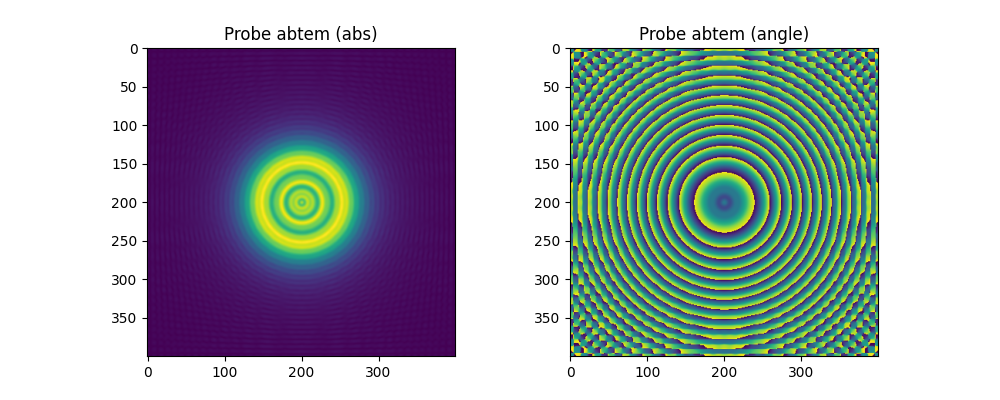

In [123]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(np.abs(probe.build(lazy=False).array))
ax1.set_title('Probe abtem (abs)');
ax2.imshow(np.angle(probe.build(lazy=False).array))
ax2.set_title('Probe abtem (angle)');

In [124]:
def simulate_pattern(object, probe, prop_kernel):
    wavefront = probe
    wavefronts = []

    for i in range(object.shape[0]):
        wavefront = wavefront * object[i]
        wavefront = convolve2d(wavefront, prop_kernel)
        wavefronts.append(wavefront)
    
    exit_wave = wavefront
    
    detector_wavefront = jnp.fft.fftshift(
        jnp.fft.fft2(wavefront)
    )
    diffraction_pattern = (
        jnp.square(detector_wavefront.real)
        + jnp.square(detector_wavefront.imag)
    )
    return exit_wave, diffraction_pattern, jnp.stack(wavefronts)

simulate_pattern_jit = jax.jit(simulate_pattern)

In [125]:
# Extract sampling as separate values to ensure proper type handling
sampling_x, sampling_y = probe.grid.sampling[0], probe.grid.sampling[1]

fresnel_propagator = fresnel_propagation_kernel(
    probe.grid.gpts[0],
    probe.grid.gpts[1],
    (sampling_x, sampling_y),  # Pass as tuple explicitly
    z=base_slice_thickness,
    energy=probe.energy,
)

angular_spectrum_propagator = angular_spectrum_propagation_kernel(
    probe.grid.gpts[0],
    probe.grid.gpts[1],
    (sampling_x, sampling_y),  # Pass as tuple explicitly
    z=base_slice_thickness,
    energy=probe.energy,
)


exit_wave_fresnel, diffraction_pattern_fresnel, wavefronts_fresnel = simulate_pattern_jit(transmit, probe_array, fresnel_propagator)
exit_wave_as, diffraction_pattern_as, wavefronts_as = simulate_pattern_jit(transmit, probe_array, angular_spectrum_propagator)

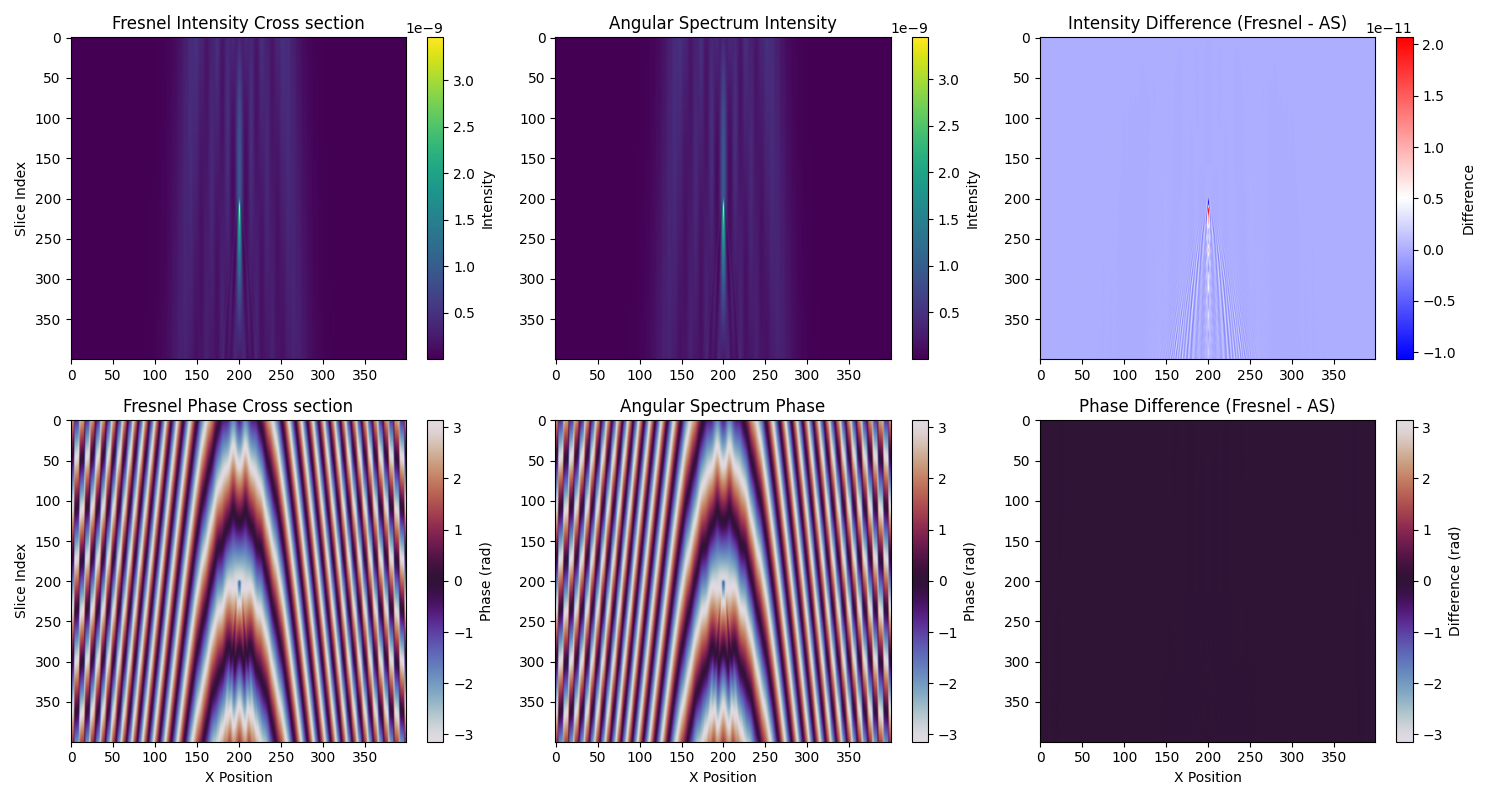

In [126]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# Calculate intensities
intensity_fresnel = np.abs(wavefronts_fresnel[:, wavefronts_fresnel.shape[1]//2, :])**2
intensity_as = np.abs(wavefronts_as[:, wavefronts_as.shape[1]//2, :])**2
intensity_diff = intensity_fresnel - intensity_as

# Calculate phases
phase_fresnel = np.angle(wavefronts_fresnel[:, wavefronts_fresnel.shape[1]//2, :])
phase_as = np.angle(wavefronts_as[:, wavefronts_as.shape[1]//2, :])
phase_diff = phase_fresnel - phase_as
# Wrap phase difference to [-pi, pi]
phase_diff = (phase_diff + np.pi) % (2 * np.pi) - np.pi

# --- Row 1: Intensity ---

# Plot Fresnel Intensity
ax[0, 0].imshow(intensity_fresnel, aspect='auto', origin='upper')
ax[0, 0].set_title("Fresnel Intensity Cross section")
ax[0, 0].set_ylabel("Slice Index")

# Plot Angular Spectrum Intensity
ax[0, 1].imshow(intensity_as, aspect='auto', origin='upper')
ax[0, 1].set_title("Angular Spectrum Intensity")

# Plot Intensity Difference
im_diff_int = ax[0, 2].imshow(intensity_diff, aspect='auto', origin='upper', cmap='bwr')
ax[0, 2].set_title("Intensity Difference (Fresnel - AS)")

# Add colorbars for intensity
fig.colorbar(ax[0, 0].images[0], ax=ax[0, 0], label="Intensity")
fig.colorbar(ax[0, 1].images[0], ax=ax[0, 1], label="Intensity")
fig.colorbar(im_diff_int, ax=ax[0, 2], label="Difference")

# --- Row 2: Phase ---

# Plot Fresnel Phase
ax[1, 0].imshow(phase_fresnel, aspect='auto', origin='upper', cmap='twilight')
ax[1, 0].set_title("Fresnel Phase Cross section")
ax[1, 0].set_xlabel("X Position")
ax[1, 0].set_ylabel("Slice Index")

# Plot Angular Spectrum Phase
ax[1, 1].imshow(phase_as, aspect='auto', origin='upper', cmap='twilight')
ax[1, 1].set_title("Angular Spectrum Phase")
ax[1, 1].set_xlabel("X Position")

# Plot Phase Difference
im_diff_phase = ax[1, 2].imshow(phase_diff, aspect='auto', origin='upper', cmap='twilight', vmin=-np.pi, vmax=np.pi)
ax[1, 2].set_title("Phase Difference (Fresnel - AS)")
ax[1, 2].set_xlabel("X Position")

# Add colorbars for phase
fig.colorbar(ax[1, 0].images[0], ax=ax[1, 0], label="Phase (rad)")
fig.colorbar(ax[1, 1].images[0], ax=ax[1, 1], label="Phase (rad)")
fig.colorbar(im_diff_phase, ax=ax[1, 2], label="Difference (rad)")

plt.tight_layout()

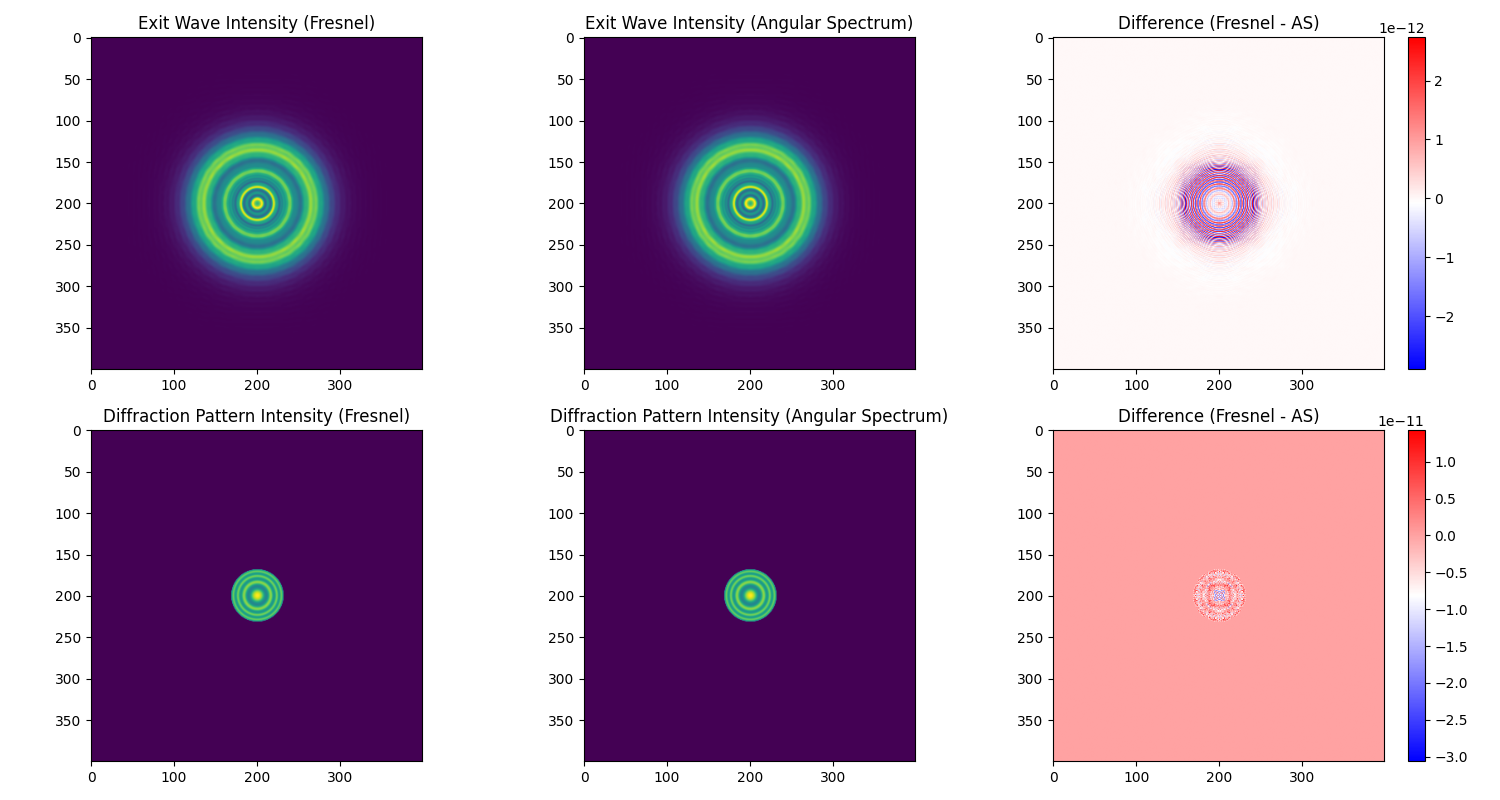

In [127]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

# --- Row 1: Exit Wave ---

# Fresnel
axs[0, 0].imshow(np.abs(exit_wave_fresnel[:, :])**2)
axs[0, 0].set_title("Exit Wave Intensity (Fresnel)")

# Angular Spectrum
axs[0, 1].imshow(np.abs(exit_wave_as[:, :])**2)
axs[0, 1].set_title("Exit Wave Intensity (Angular Spectrum)")

# Difference
diff_exit_wave = np.abs(exit_wave_fresnel[:, :])**2 - np.abs(exit_wave_as[:, :])**2
im_diff_ew = axs[0, 2].imshow(diff_exit_wave, cmap='bwr')
axs[0, 2].set_title("Difference (Fresnel - AS)")
fig.colorbar(im_diff_ew, ax=axs[0, 2])

# --- Row 2: Diffraction Pattern ---

# Fresnel
axs[1, 0].imshow(np.abs(diffraction_pattern_fresnel[:, :])**2)
axs[1, 0].set_title("Diffraction Pattern Intensity (Fresnel)")

# Angular Spectrum
axs[1, 1].imshow(np.abs(diffraction_pattern_as[:, :])**2)
axs[1, 1].set_title("Diffraction Pattern Intensity (Angular Spectrum)")

# Difference
diff_dp = np.abs(diffraction_pattern_fresnel[:, :])**2 - np.abs(diffraction_pattern_as[:, :])**2
im_diff_dp = axs[1, 2].imshow(diff_dp, cmap='bwr')
axs[1, 2].set_title("Difference (Fresnel - AS)")
fig.colorbar(im_diff_dp, ax=axs[1, 2])

plt.tight_layout()